In [1]:
import os 
import glob
import numpy as np 
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd

from utils.plots import *
from utils.drl import *
from rl.agent import *
import rl.plots as rlplt
from utils.stats_perform import *
import warnings
warnings.filterwarnings("ignore")

In [2]:
fig_dir = os.path.join('figures','rl','lhb_data')
fig_dir_beta = os.path.join('figures','lhb_data','per_beta')
simulations_dir ='/Users/sromeropinto/Library/CloudStorage/GoogleDrive-sromeropinto@g.harvard.edu/My Drive/Data/LHb_Analysis/Analysis/BiophysicalModel/lhb_data/rl'
g_names = ['control','lesion']
taus_dic = np.load( os.path.join('analysis','biophysical_model','taus_rec_occ_vs_da_level_population_0923.npz'),allow_pickle=True )
taus_lin = taus_dic['taus_lin']
taus_dic_data=np.load(os.path.join('analysis','lhb_data','drl_metrics_from_data_0923.npz'),allow_pickle=True )
taus_c = taus_dic_data['tau_control']
taus_l = taus_dic_data['tau_lesion']
taus_g = [taus_c,taus_l]

**Load the RL simulations**

- Types of simulations are {`sampling_`, `nosampling_nodistr_`, `nosampling_nodistr_`}  
- *Note*: Look at notebook `rl_simulations_from_data` for detailed definitions on the simulation types

## Figure 6k-l
Perform the plot for the simulations `sampling`  for a given value of decay factor $\beta$
- Mean of value predictors and TD errors at cue onset for each group
- Mean of baseline distributions for the value predictors for each group



The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis cannot be rejected
The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution

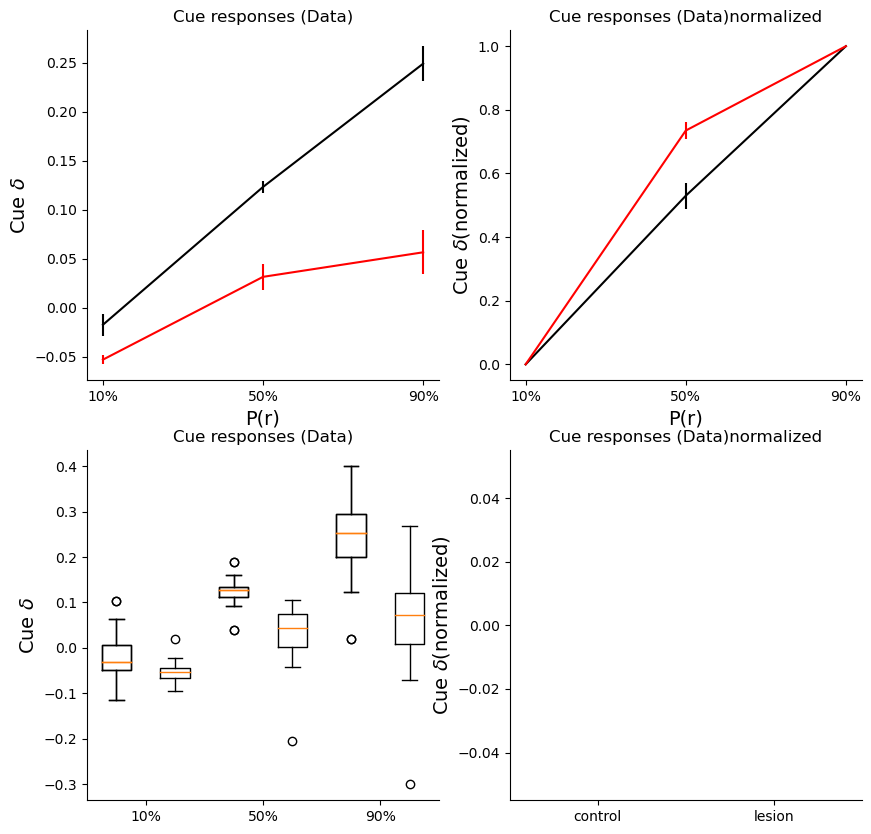

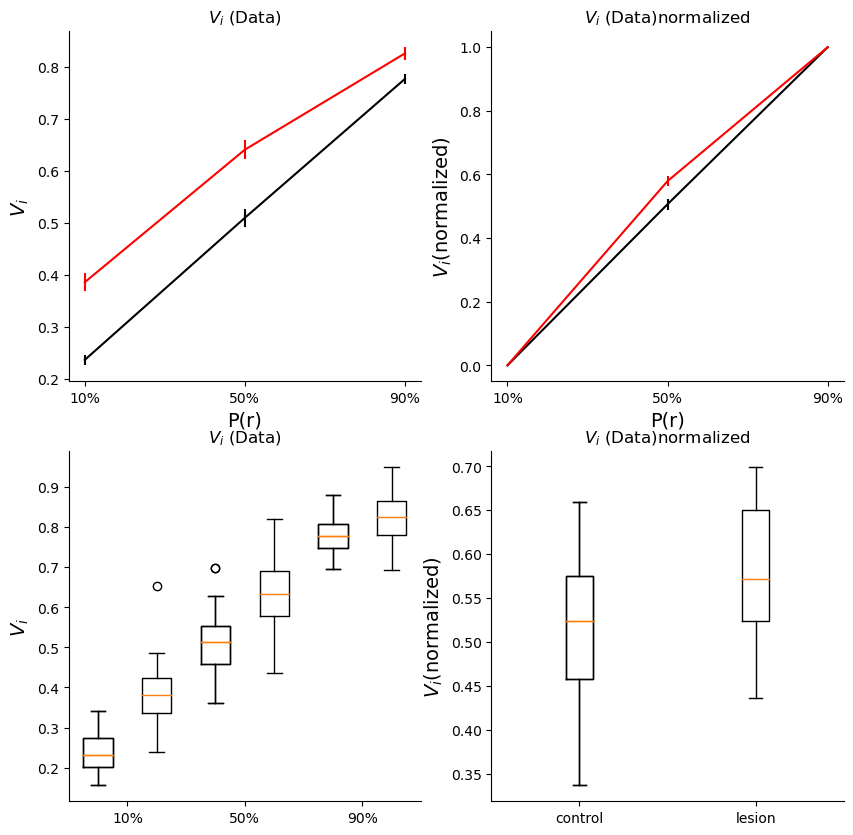

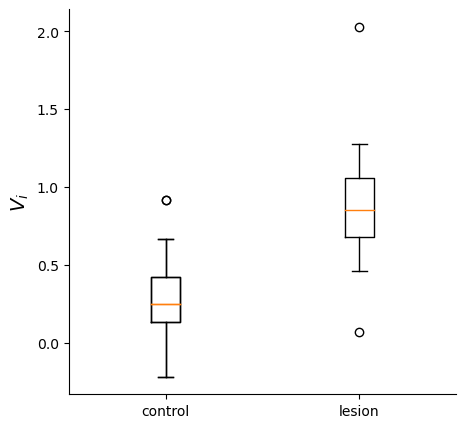

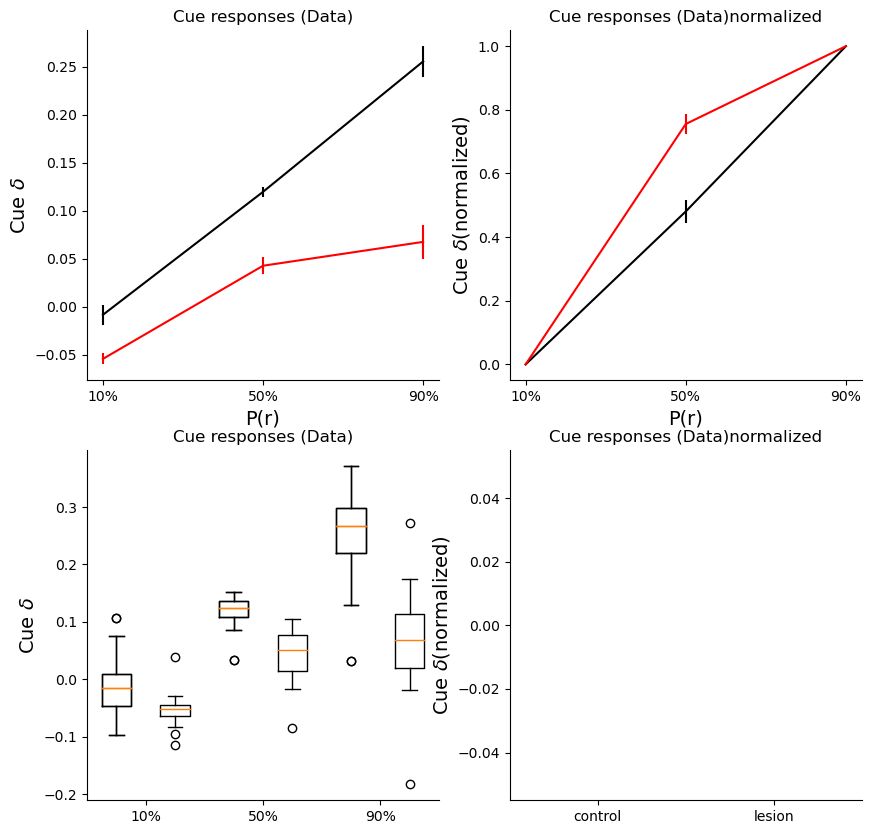

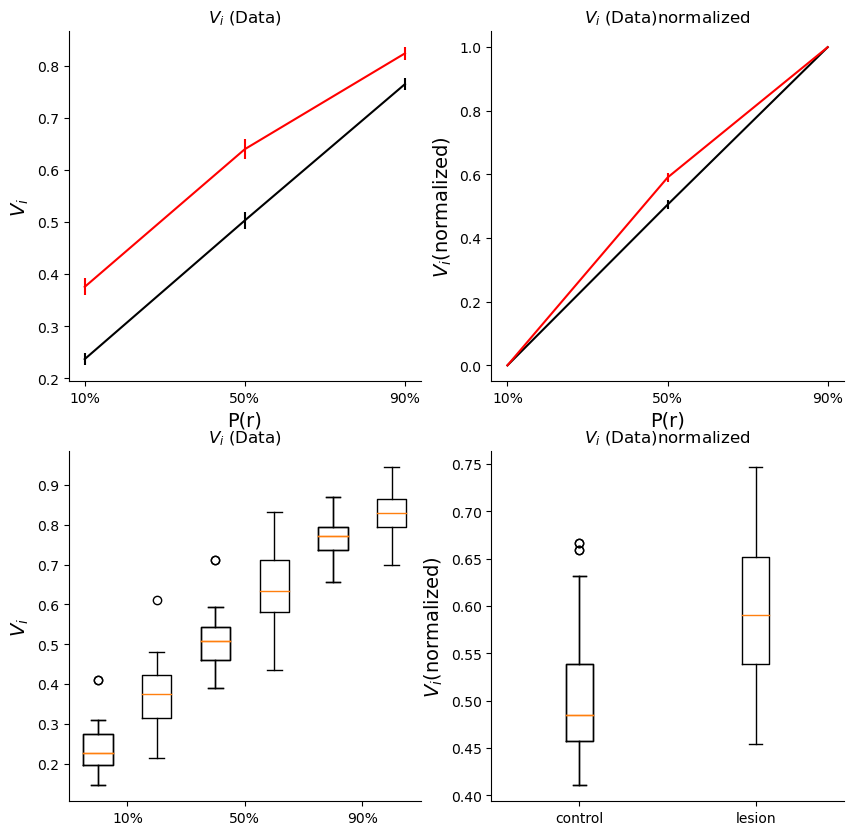

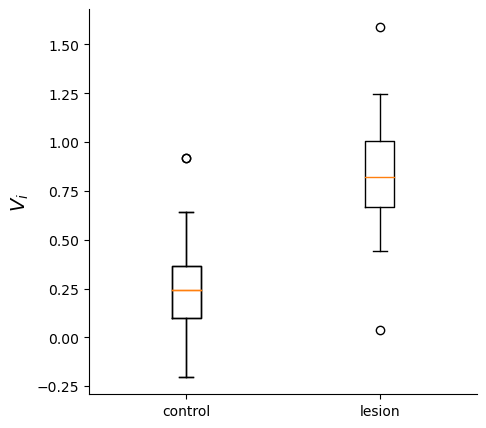

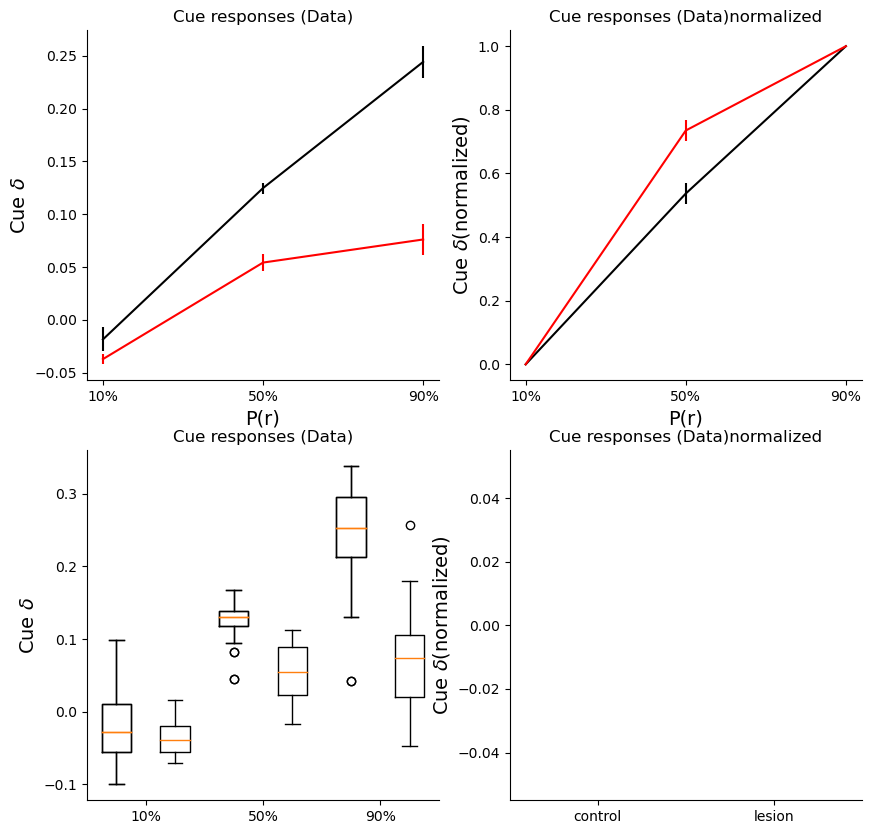

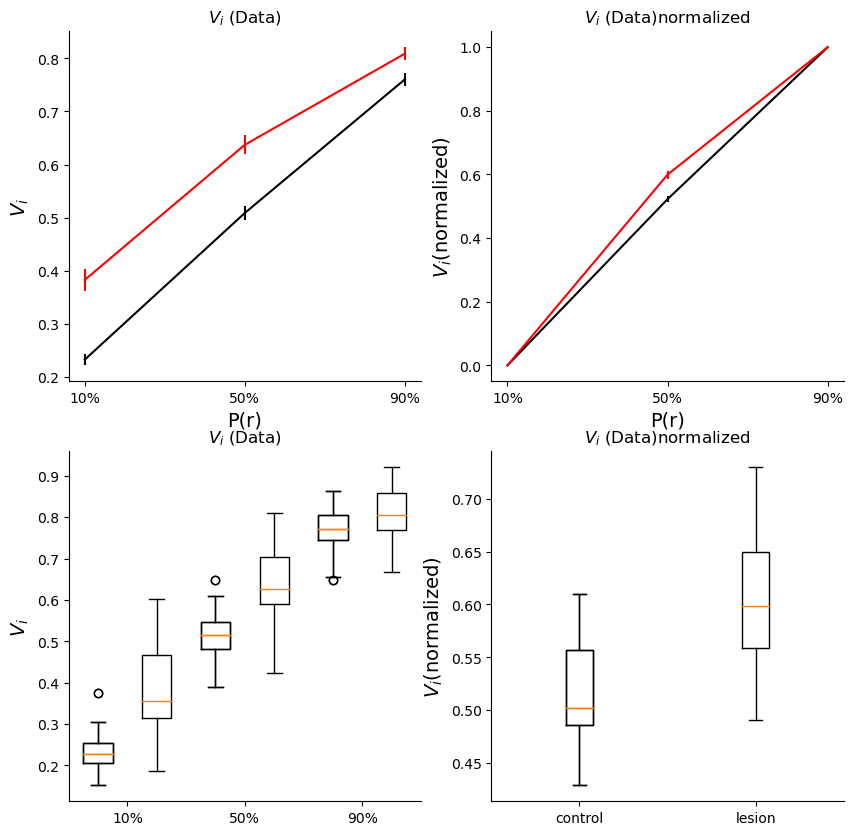

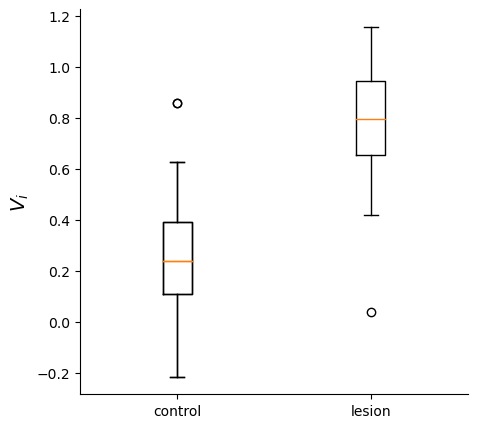

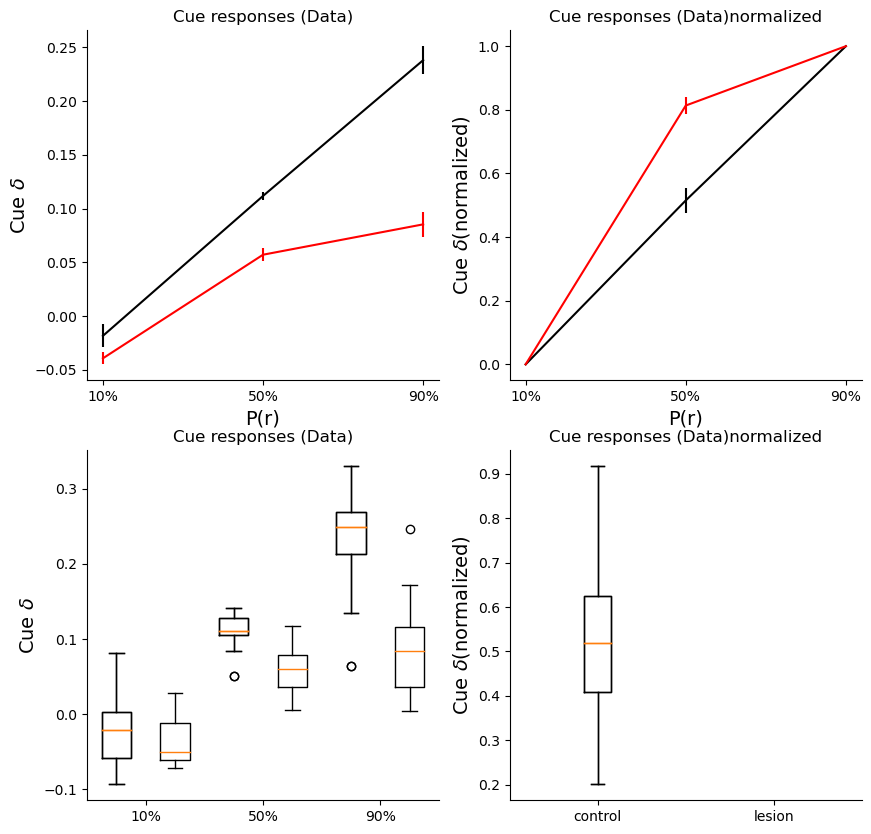

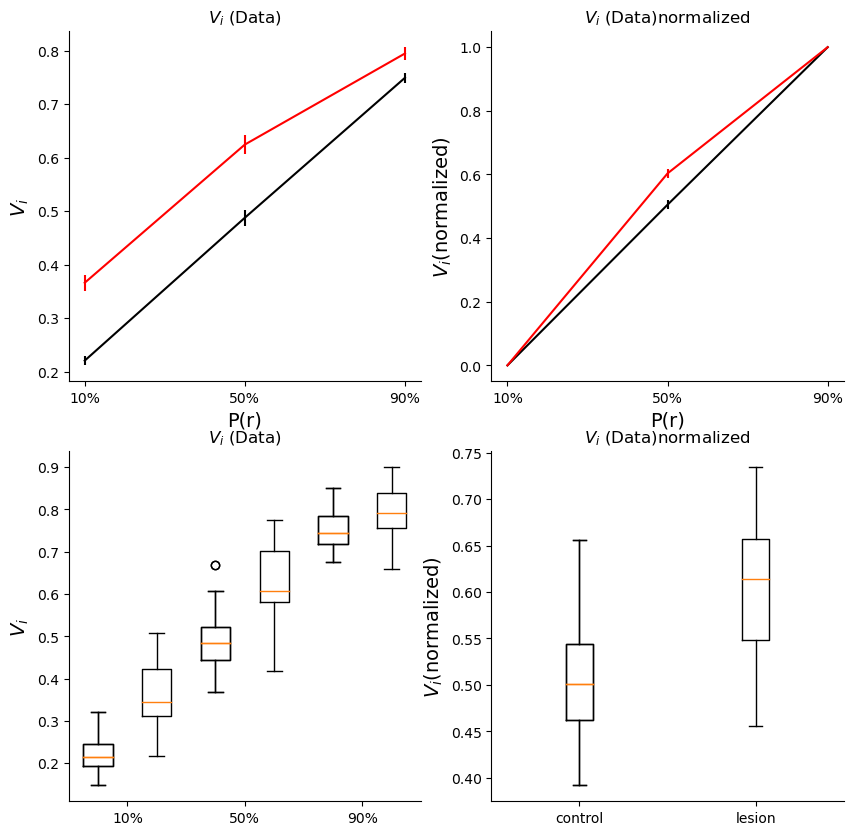

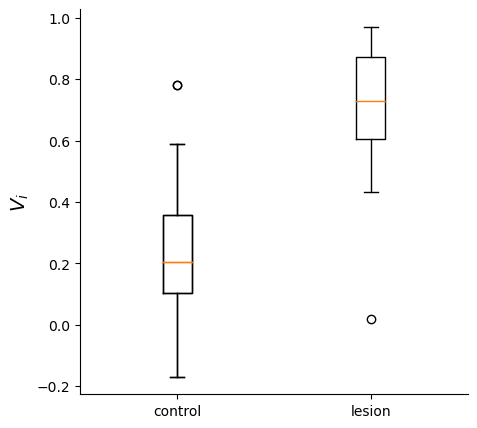

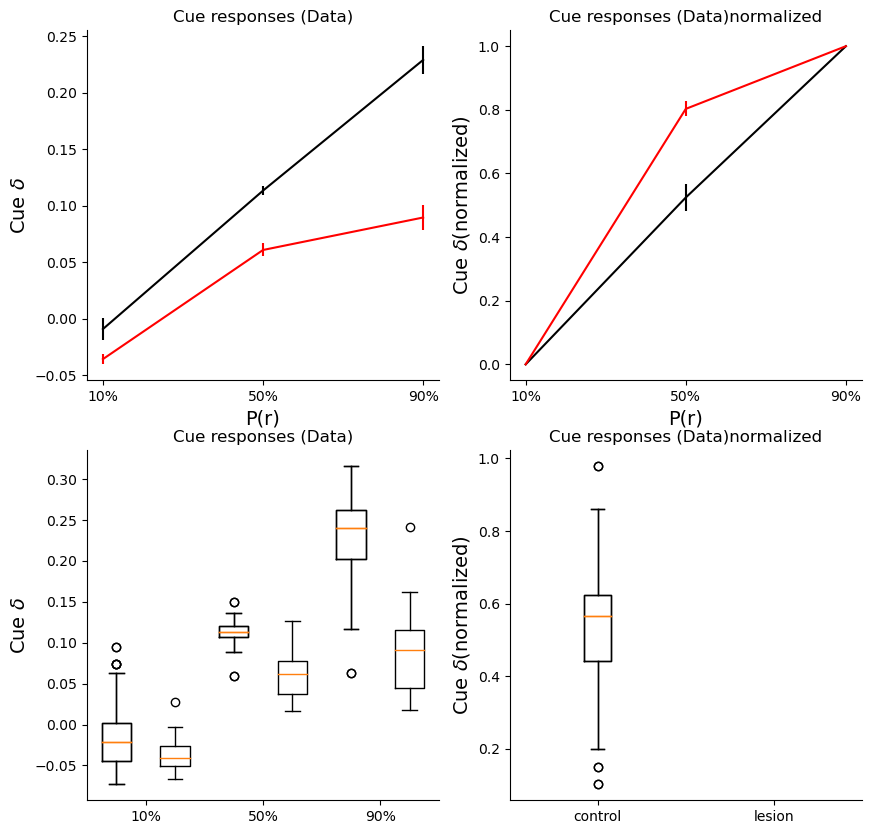

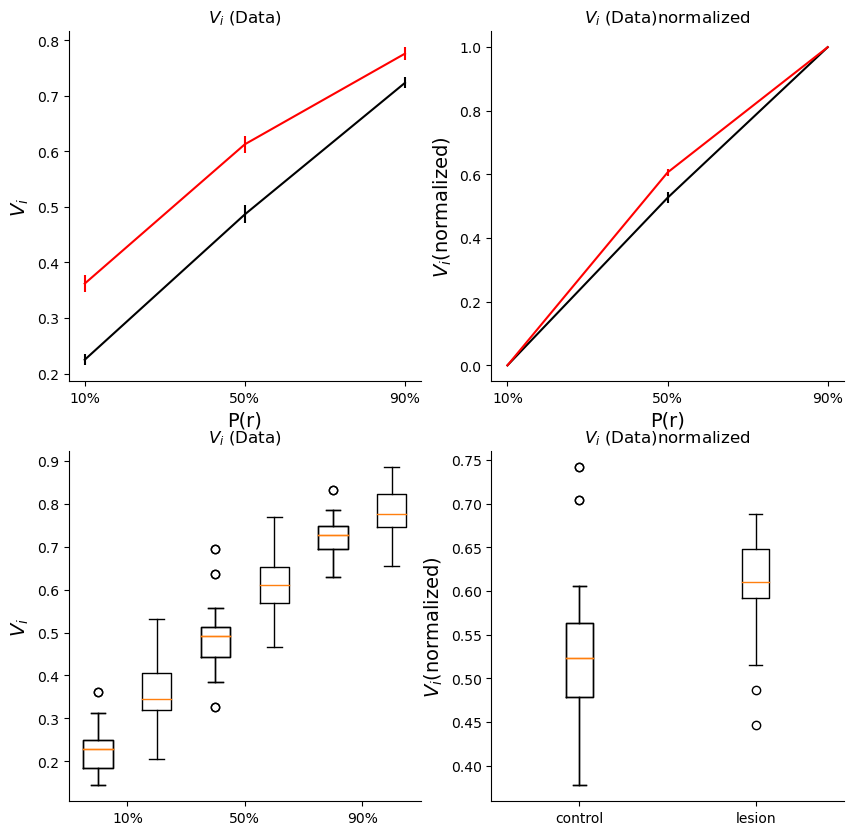

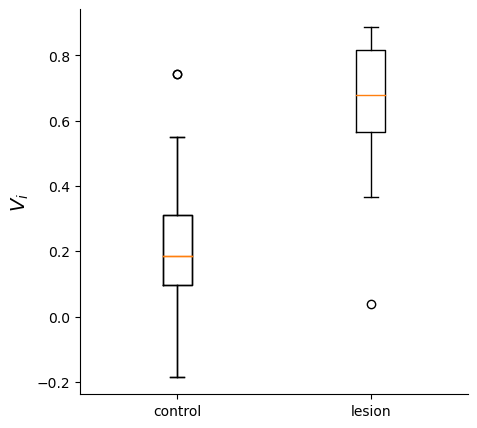

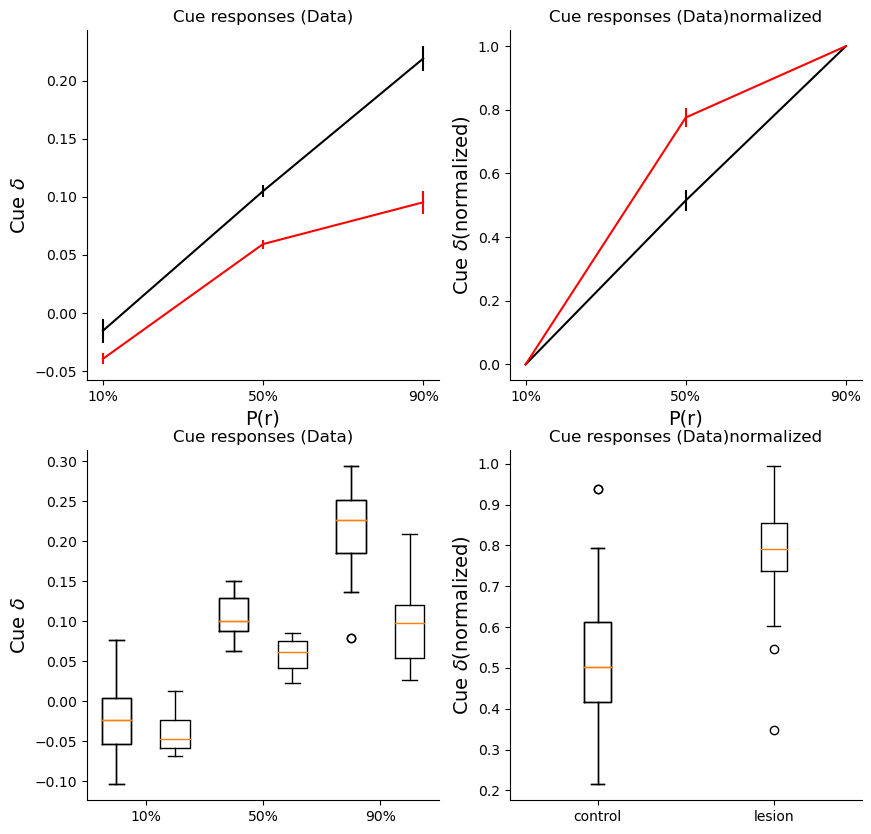

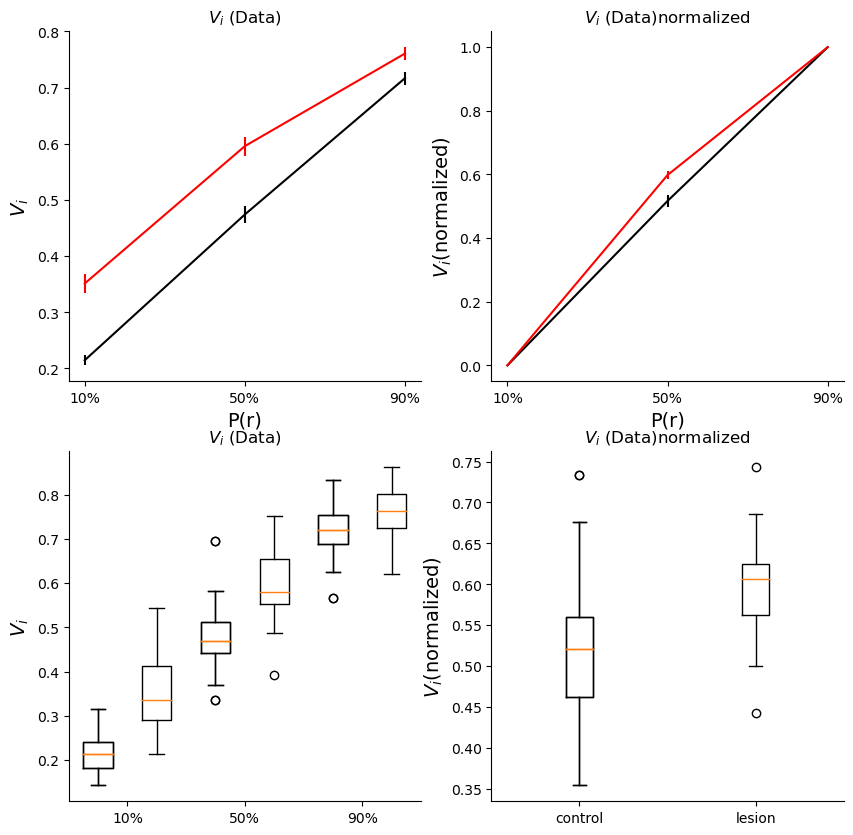

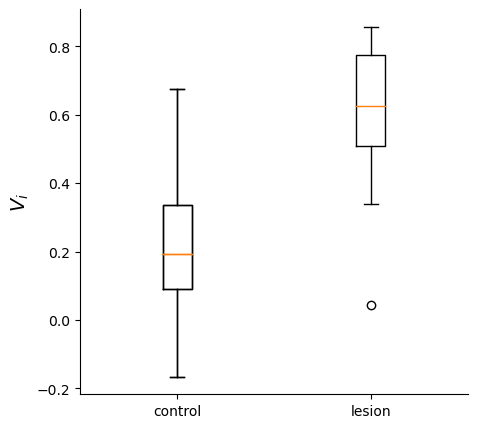

In [3]:
sim_type = 'sampling_'
#  'nosampling_'
#  'nosampling_nodistr_'
#   'sampling_'
file_type = 'results_sim_type_eta_' + sim_type + 'eps_'
beta_v = [0.001,0.002,0.005,0.01,0.015,0.02] 
cs_names = ['10%','50%','90%']
i_group = 0
ieps=0
taus_=np.sort(taus_g[i_group])
eta_ = np.nanmean(taus_lin[i_group,:])
taus_ = taus_[(taus_>0)*(taus_<1)]
epsilon_ = beta_v[ieps]
agent = create_instance_agent_pav_task(taus_l,eta_,epsilon_)
colors_g = ['black','red']

mu_ieps=dict()
mu_ieps['cue_response_mean']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['vi_mean']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['cue_response_mean_n']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['vi_mean_n']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['cue_response_mean_std']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['vi_mean_std']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['cue_response_mean_n_std']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['vi_mean_n_std']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['baseline_vi_mean']=   np.nan*np.ones((len(beta_v),2))
mu_ieps['baseline_vi_mean_std']=   np.nan*np.ones((len(beta_v),2))
for i_eps in range(len(beta_v)):
    eps = beta_v[i_eps]
    eps_str = str(eps).replace('.','_')
    simulation_type = 'Data_' + sim_type + 'beta_' + eps_str
    file_list = glob.glob(os.path.join(simulations_dir ,file_type + eps_str +'_control_*'))
    results_control = [np.load(ifile, allow_pickle=True).flatten()[0] for ifile in file_list]
    file_list = glob.glob(os.path.join(simulations_dir ,file_type + eps_str +'_lesion_*'))
    results_lesion = [np.load(ifile, allow_pickle=True).flatten()[0] for ifile in file_list]
    results_l = [rr for rr in results_lesion if len(rr)>0 ]
    results_c = [rr for rr in results_control if len(rr)>0 ]
    #% % Plot means 
    results_v=[results_c,results_l]
    evtype = 'mean'
    vars_n = ['deltas_trials_full','distribution_trials_full']
    save_titles = ['cue_response_mean','vi_mean']
    y_labels = [r'Cue $\delta$',r'$V_i$']
    id_states = [1,3]
    
    id_cs_plot = np.arange(3)
    id_iter_plot = np.arange(0,len(results_c))
    plot_titles = [r'Cue responses (Data)',r'$V_i$ (Data)']
    rlplt.plot_mean_per_trial_batch_iterations(agent,results_v,vars_n,id_states,save_titles,plot_titles,y_labels,cs_names,g_names,
                                         id_cs_plot,id_iter_plot,simulation_type,fig_dir,colors_g,evtype =evtype)    
    # Stats on mean responses 
    for iv in  np.arange(len(vars_n)):
        var = vars_n[iv]
        id_state = id_states[iv]
        var_mu, var_mu_n = rlplt.get_mean_response_across_iterations(results_v,var,id_state,evtype)
        groups_test =[[var_mu[0,:,ics],var_mu[1,:,ics]] for ics in range(3)]
        name_suff,name_preff = cs_names,save_titles[iv] + '_'+ str(eps)
        if iv==0 and i_eps==0:
            tests_pd = get_tests_table(groups_test, name_preff, name_suff,restart_pd = True )
        else:
            tests_pd = get_tests_table(groups_test, name_preff, name_suff,tests_pd = tests_pd )
        groups_test =[[var_mu_n[0,:,1],var_mu_n[1,:,1]]]
        name_suff,name_preff = cs_names[1], save_titles[iv] + '_norm' + '_'+ str(eps)
        tests_pd = get_tests_table(groups_test, name_preff, name_suff,tests_pd = tests_pd )

        mu_ieps[save_titles[iv]][i_eps,:,:]= np.nanmean(var_mu,axis=1)
        mu_ieps[save_titles[iv]+ '_std'][i_eps,:,:]= np.nanstd(var_mu,axis=1)/np.sqrt(var_mu.shape[1])
        mu_ieps[save_titles[iv] + '_n'][i_eps,:,:]= np.nanmean(var_mu_n,axis=1)
        mu_ieps[save_titles[iv]+ '_n_std'][i_eps,:,:]= np.nanstd(var_mu_n,axis=1)/np.sqrt(var_mu_n.shape[1])

    # Plot distribution of baseline: 
    var = 'distribution_trials_full'
    id_state = 0
    title_var =r'$V_i$ baseline (Data)'
    y_title = r'$V_i$'
    save_tit = 'baseline_vi_mean'
    base_resp_g = rlplt.plot_var_baseline_iterations(agent,results_v,var, y_title,g_names,id_state,id_iter_plot,
                                simulation_type,save_tit,fig_dir,evtype = 'tau')
    tests_pd = get_tests_table([base_resp_g], save_tit, 'all'+ '_'+ str(eps),tests_pd = tests_pd )
    mu_ieps[save_tit][i_eps,:]=np.asarray([np.nanmean(bb) for bb in base_resp_g])
    mu_ieps[save_tit+ '_std'][i_eps,:]=np.asarray([np.nanstd(bb)/np.sqrt(len(bb)) for bb in base_resp_g])

tests_pd.to_excel("analysis/rl_" + sim_type +".xlsx")  

